# UROP Research Log - May 26, 2026

## Objective
Establish a Standard Close baseline by computing the daily tracking error between PBP ETF (market price) and the BXM Index for the full year 2022.
This baseline will later serve as the "before" benchmark in our synchronicity analysis (Standard CLose vs. 2:55 PM CT synchronized close).

## Data Sources
- PBP ETF daily price: Nasdaq Historical Data (nasdaq.com), Market Price Close
- BXM Index daily level: Cboe Global Markets official CDN (cdn.cboe.com/api/global/us_indices/daily_prices/BXM_History.csv)

## Approach
1. Load both CSVs, filter to 2022
2. Align dates, compute daily log returns
3. Compute daily tracking error = $R_{PBP} - R_{BXM}$
4. Summarize : mean TE, annualized TE (std), plot

## Known Limitations
- PBP close = 4:00 PM ET (Cboe BZX equity market close)
- BXM close = based on SPX options settlement, ~4:15 PM ET
- This mismatch IS the synchronicity problem we are documenting
- Data source (Nasdaq) is for testing only; final paper will use Bloomberg/WRDS if possible

## Qualitative Tracking Error Sources (from PBP Prospectus)
Based on review of the Invesco PBP Statutory Prospectus and SAI:

1. **Sampling (not full replication)**: The fund may hold only a subset of 
   index constituents when full replication is impractical. Invesco explicitly 
   acknowledges this increases tracking error relative to full replication.

2. **Liquidity-driven execution delay (Smearing)**: The fund may delay or 
   spread trades due to liquidity constraints, meaning option rolls do not 
   occur at the exact time prescribed by the BXM index methodology 
   (3rd Friday of each month).

3. **90% investment rule**: At least 90% (not 100%) of assets must be 
   invested in index constituents, leaving up to 10% discretionary room.

4. **Discretionary deviations**: The fund may deviate from the index for 
   tax efficiency, cash management, or large redemption events.

These structural differences between the ETF and the index represent 
*qualitative* tracking error — distinct from the *quantitative* 
synchronicity-driven tracking error this notebook measures.

In [9]:
# -- Imports & Data Load --
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -- Load PBP (Nasdaq) --
pbp = pd.read_csv(r"..\data\raw\HistoricalData_PBP.csv")

# -- Load BXM (Cboe) --
bxm = pd.read_csv(r"..\data\raw\BXM_History.csv")

print("PBP shape:", pbp.shape)
print(pbp.head(3))
print("BXM shape:", bxm.shape)
print(bxm.head(3))

PBP shape: (1255, 6)
         Date  Close/Last  Volume   Open   High      Low
0  05/26/2026       22.77   39375  22.78  22.79  22.7177
1  05/22/2026       22.71   27247  22.75  22.78  22.6750
2  05/21/2026       22.66   37020  22.60  22.67  22.5100
BXM shape: (6080, 2)
         DATE     BXM
0  03/22/2002  584.30
1  03/25/2002  578.48
2  03/26/2002  581.43


In [10]:
# -- Filtering to 2022 & Parse Dates --

# PBP: parse date, filter 2022
pbp["Date"] = pd.to_datetime(pbp["Date"])
pbp_2022 = pbp[pbp["Date"].dt.year == 2022].copy()
pbp_2022 = pbp_2022.sort_values("Date").reset_index(drop=True)

# BXM: parse date, filter 2022
bxm["DATE"] = pd.to_datetime(bxm["DATE"])
bxm_2022 = bxm[bxm["DATE"].dt.year == 2022].copy()
bxm_2022 = bxm_2022.sort_values("DATE").reset_index(drop=True)

print("PBP 2022 rows:", len(pbp_2022))
print(pbp_2022.head(3))
print("BXM 2022 rows:", len(bxm_2022))
print(bxm_2022.head(3))

PBP 2022 rows: 251
        Date  Close/Last  Volume   Open   High    Low
0 2022-01-03       23.22  202782  23.18  23.31  23.11
1 2022-01-04       23.14   66310  23.24  23.24  23.13
2 2022-01-05       23.08   36773  23.12  23.22  23.05
BXM 2022 rows: 251
        DATE      BXM
0 2022-01-03  1778.59
1 2022-01-04  1778.63
2 2022-01-05  1767.15


In [11]:
# -- Merge & Compute Daily Log Returns --

# Rename columns for clarity
pbp_2022 = pbp_2022.rename(columns={"Date": "date", "Close/Last": "pbp_close"})
bxm_2022 = bxm_2022.rename(columns={"DATE": "date", "BXM": "bxm_close"})

# Merge on date (inner join - keep only matching trading days)
df = pd.merge(
    pbp_2022[["date","pbp_close"]],
    bxm_2022[["date","bxm_close"]],
    on="date",
    how="inner"
)

# Compute daily log returns
df["r_pbp"] = np.log(df["pbp_close"] / df["pbp_close"].shift(1))
df["r_bxm"] = np.log(df["bxm_close"] / df["bxm_close"].shift(1))

# Drop first row (NaN from shift)
df = df.dropna().reset_index(drop=True)

print("Merged rows:", len(df))
print(df.head(5))

Merged rows: 250
        date  pbp_close  bxm_close     r_pbp     r_bxm
0 2022-01-04     23.140    1778.63 -0.003451  0.000022
1 2022-01-05     23.080    1767.15 -0.002596 -0.006475
2 2022-01-06     23.080    1768.30  0.000000  0.000651
3 2022-01-07     23.090    1768.79  0.000433  0.000277
4 2022-01-10     23.035    1768.32 -0.002385 -0.000266


In [12]:
# -- Tracking Error Calculation --

# Daily TE = r_pbp - r_bxm
df["te_daily"] = df["r_pbp"] - df["r_bxm"]

# Summary statistics
mean_te   = df["te_daily"].mean()
std_te    = df["te_daily"].std()
ann_te    = std_te * np.sqrt(252)   # Annualized TE

print("=== Baseline Tracking Error (Standard Close, 2022) ===")
print(f"Mean Daily TE      : {mean_te:.6f}  ({mean_te*100:.4f}%)")
print(f"Std Dev Daily TE   : {std_te:.6f}  ({std_te*100:.4f}%)")
print(f"Annualized TE      : {ann_te:.6f}  ({ann_te*100:.4f}%)")
print(f"Max Daily TE       : {df['te_daily'].max():.6f}")
print(f"Min Daily TE       : {df['te_daily'].min():.6f}")

=== Baseline Tracking Error (Standard Close, 2022) ===
Mean Daily TE      : -0.000080  (-0.0080%)
Std Dev Daily TE   : 0.003024  (0.3024%)
Annualized TE      : 0.047997  (4.7997%)
Max Daily TE       : 0.007793
Min Daily TE       : -0.009728


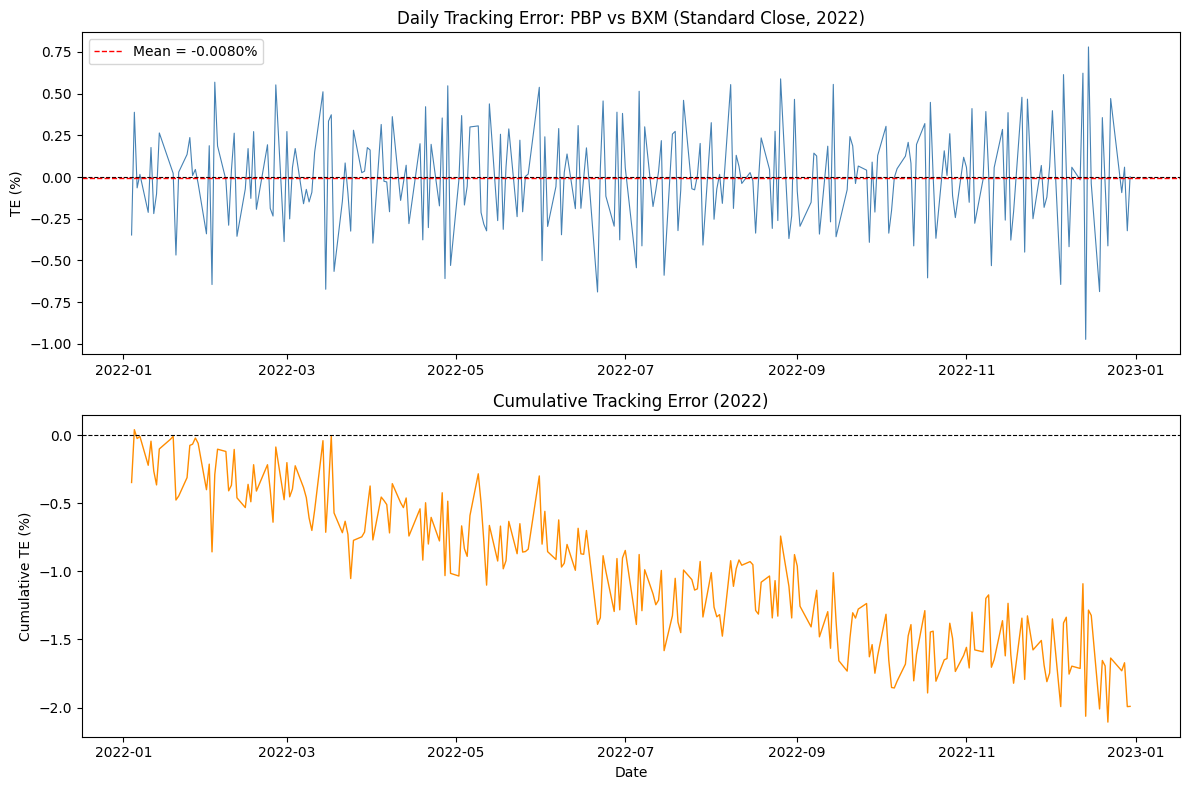

Plot saved to data/processed/


In [13]:
# -- Visualization --

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Daily Tracking Error
axes[0].plot(df["date"], df["te_daily"] * 100, color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].axhline(mean_te * 100, color="red", linewidth=1, linestyle="--", label=f"Mean = {mean_te*100:.4f}%")
axes[0].set_title("Daily Tracking Error: PBP vs BXM (Standard Close, 2022)")
axes[0].set_ylabel("TE (%)")
axes[0].legend()

# Plot 2: Cumulative Tracking Error
axes[1].plot(df["date"], df["te_daily"].cumsum() * 100, color="darkorange", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Cumulative Tracking Error (2022)")
axes[1].set_ylabel("Cumulative TE (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.savefig("../data/processed/baseline_TE_2022.png", dpi=150)
plt.show()
print("Plot saved to data/processed/")

## Results Summary (May 26, 2026)

| Metric | Value |
|--------|-------|
| Mean Daily TE | -0.0080% |
| Std Dev Daily TE | 0.3024% |
| Annualized TE | **4.80%** |
| Max Daily TE | +0.78% |
| Min Daily TE | -0.97% |

## Interpretation
- Negative mean TE reflects structural underperformance of ETF vs. index,
  driven by expense ratio and qualitative tracking error sources.
- Random positive/negative spikes in daily TE are consistent with the 
  synchronicity problem (PBP closes at 4:00 PM ET vs. BXM at ~4:15 PM ET).
- Cumulative TE drifts to approximately -2% by year-end 2022.